In [1]:
import os 
import pandas as pd
import joblib
import numpy as np

In [ ]:
rf_model=joblib.load(os.path.join("models","Supervised_rf_model.pkl"))
scaler = joblib.load(os.path.join("scaled", "fitted_scaler.pkl"))

if hasattr(scaler, 'feature_names_in_'):
    feature_columns_names = scaler.feature_names_in_
else:
    #If due to any reason Name not found
    feature_columns_names = [f"Feature_{i}" for i in range(rf_model.n_features_in_)]

print(" Day 7: Trained Random Forest Model and Scaler loaded successfully!")
print(f"Total features detected in pipeline: {len(feature_columns_names)}")

 Day 7: Trained Random Forest Model and Scaler loaded successfully!
Total features detected in pipeline: 65


In [ ]:
import pandas as pd

# ==========================================
# RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": feature_columns_names, 
    "Importance": rf_model.feature_importances_
})

# Highest importance first
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Top 20 features
top_20_features = feature_importance.head(20)

print("=" * 70)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 70)

display(top_20_features)


TOP 20 IMPORTANT FEATURES


,Feature,Importance
36,Packet Length Max,0.087945
48,Avg Packet Size,0.084140
49,Avg Fwd Segment Size,0.075430
37,Packet Length Mean,0.068540
8,Fwd Packet Length Mean,0.067090
4,Fwd Packets Length Total,0.052141
52,Subflow Fwd Bytes,0.052084
6,Fwd Packet Length Max,0.050524
24,Fwd IAT Min,0.048834
54,Subflow Bwd Bytes,0.031393


In [ ]:

if 'iso_model' not in locals():
    iso_model = joblib.load(os.path.join("models", "unsupervised_iso_model.pkl"))
if 'X_test_scaled' not in locals():
    X_test_scaled = np.load(os.path.join("scaled", "X_test_scaled.npy"))
if 'feature_columns_names' not in locals():
    scaler = joblib.load(os.path.join("scaled", "fitted_scaler.pkl"))
    feature_columns_names = scaler.feature_names_in_

print("Analyzing Isolation Forest Feature Contributions...")


raw_contributions = np.zeros(len(feature_columns_names))


sample_size = min(5000, X_test_scaled.shape[0])
X_sample = X_test_scaled[:sample_size]


base_score = -iso_model.score_samples(X_sample)

for i in range(X_sample.shape[1]):
    X_perturbed = X_sample.copy()
    X_perturbed[:, i] = 0 
    perturbed_score = -iso_model.score_samples(X_perturbed)
    raw_contributions[i] = np.mean(np.abs(base_score - perturbed_score))

if raw_contributions.sum() > 0:
    iso_importances = raw_contributions / raw_contributions.sum()
else:
    iso_importances = raw_contributions

iso_feature_importance = pd.DataFrame({
    "Feature": feature_columns_names,
    "Anomaly_Contribution": iso_importances
})

# Highest contribution first
iso_feature_importance = iso_feature_importance.sort_values(by="Anomaly_Contribution", ascending=False)
top_20_iso_features = iso_feature_importance.head(20)

print("=" * 70)
print("TOP 20 ISOLATION FOREST ANOMALY FEATURES")
print("=" * 70)
display(top_20_iso_features)


Analyzing Isolation Forest Feature Contributions...
TOP 20 ISOLATION FOREST ANOMALY FEATURES


,Feature,Anomaly_Contribution
5,Bwd Packets Length Total,0.065466
54,Subflow Bwd Bytes,0.040713
29,Bwd IAT Min,0.038198
45,URG Flag Count,0.036264
24,Fwd IAT Min,0.035076
3,Total Backward Packets,0.034639
25,Bwd IAT Total,0.031691
18,Flow IAT Max,0.027464
51,Subflow Fwd Packets,0.025839
60,Active Min,0.024635


C:\Users\MasterLaptops\AppData\Local\Temp\ipykernel_6712\2742263671.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MasterLaptops\AppData\Local\Temp\ipykernel_6712\2742263671.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


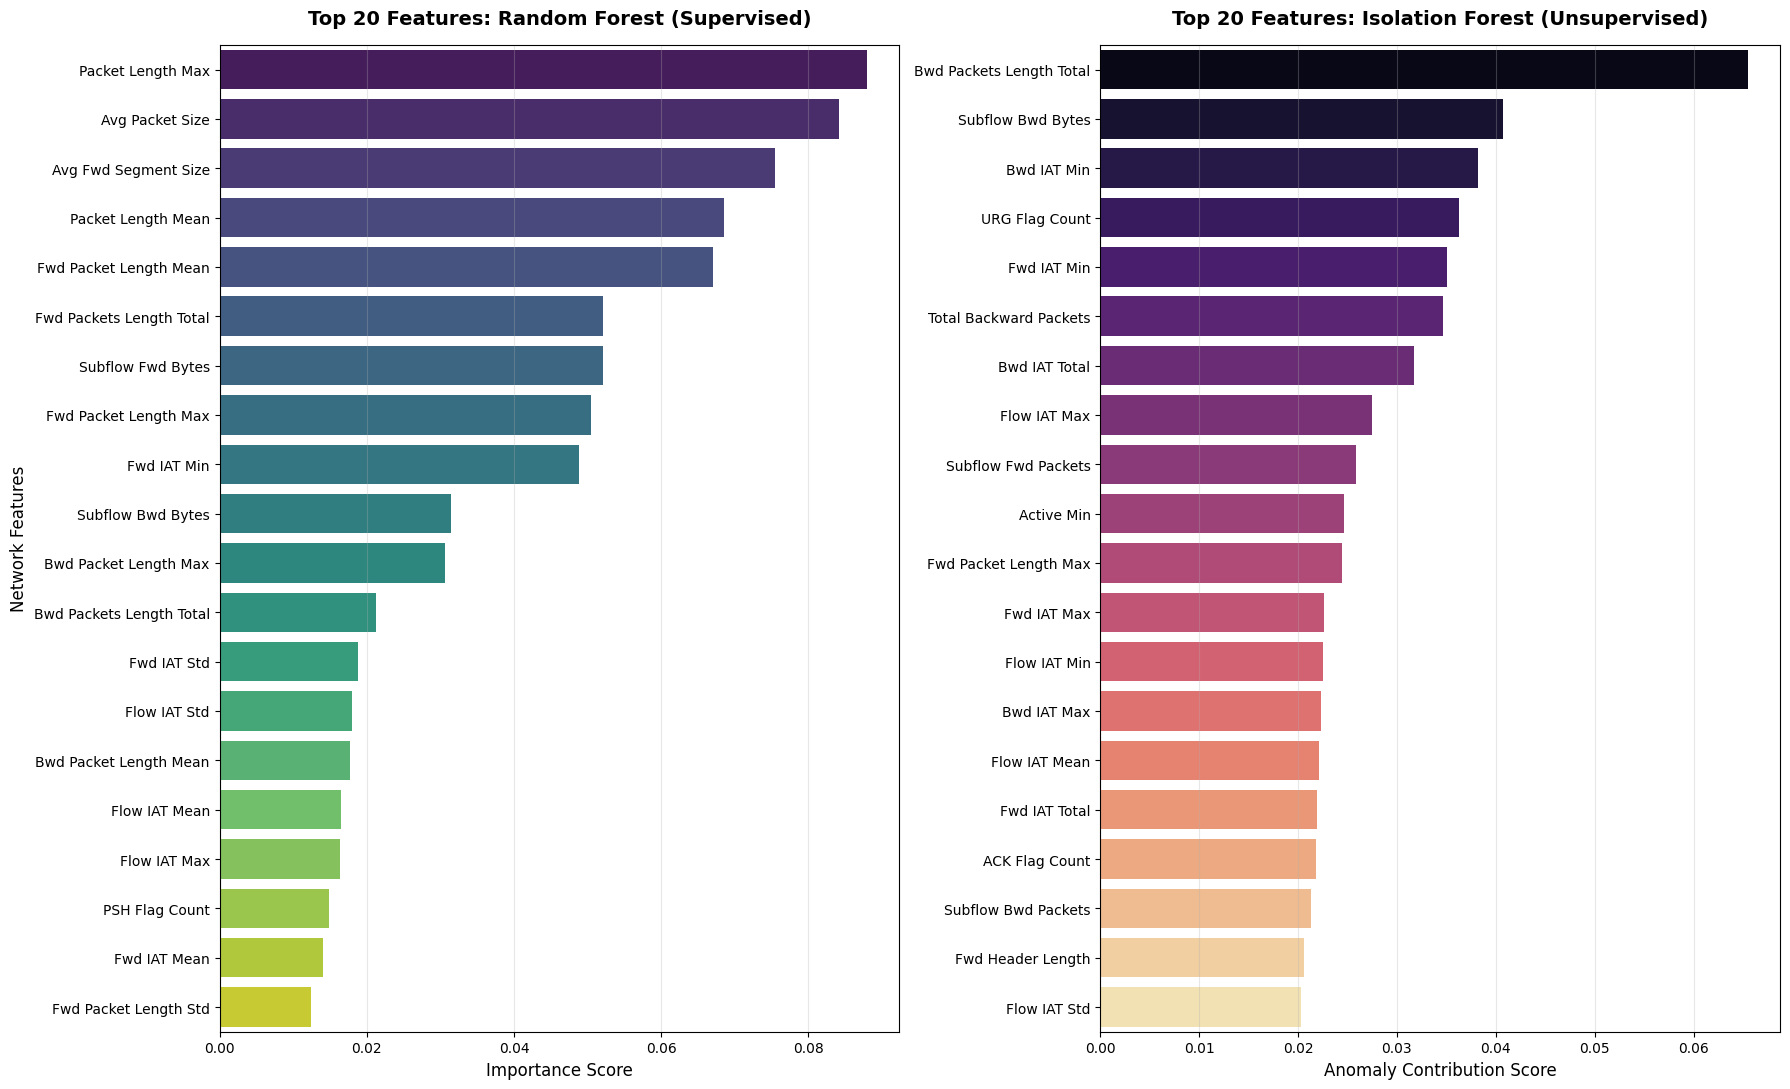

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =======================================================================
# SIDE-BY-SIDE VISUALIZATION OF TOP 20 FEATURES FOR BOTH MODELS
# =======================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 11))

# ---- GRAPH 1: Random Forest (Supervised Model) ----
# 20 features 
sns.barplot(
    x="Importance", 
    y="Feature", 
    data=top_20_features.head(20), 
    palette="viridis", 
    ax=ax1
)
ax1.set_title("Top 20 Features: Random Forest (Supervised)", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlabel("Importance Score", fontsize=12)
ax1.set_ylabel("Network Features", fontsize=12)
ax1.grid(axis="x", alpha=0.3)

# ---- GRAPH 2: Isolation Forest (Unsupervised Anomaly Model) ----
# 20 anomaly features 
sns.barplot(
    x="Anomaly_Contribution", 
    y="Feature", 
    data=top_20_iso_features.head(20), 
    palette="magma", 
    ax=ax2
)
ax2.set_title("Top 20 Features: Isolation Forest (Unsupervised)", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlabel("Anomaly Contribution Score", fontsize=12)
ax2.set_ylabel("") # Khali chora kyunki features central divide me hain
ax2.grid(axis="x", alpha=0.3)

# Layout padding perfect set kar ke display karein
plt.tight_layout()
plt.show()
